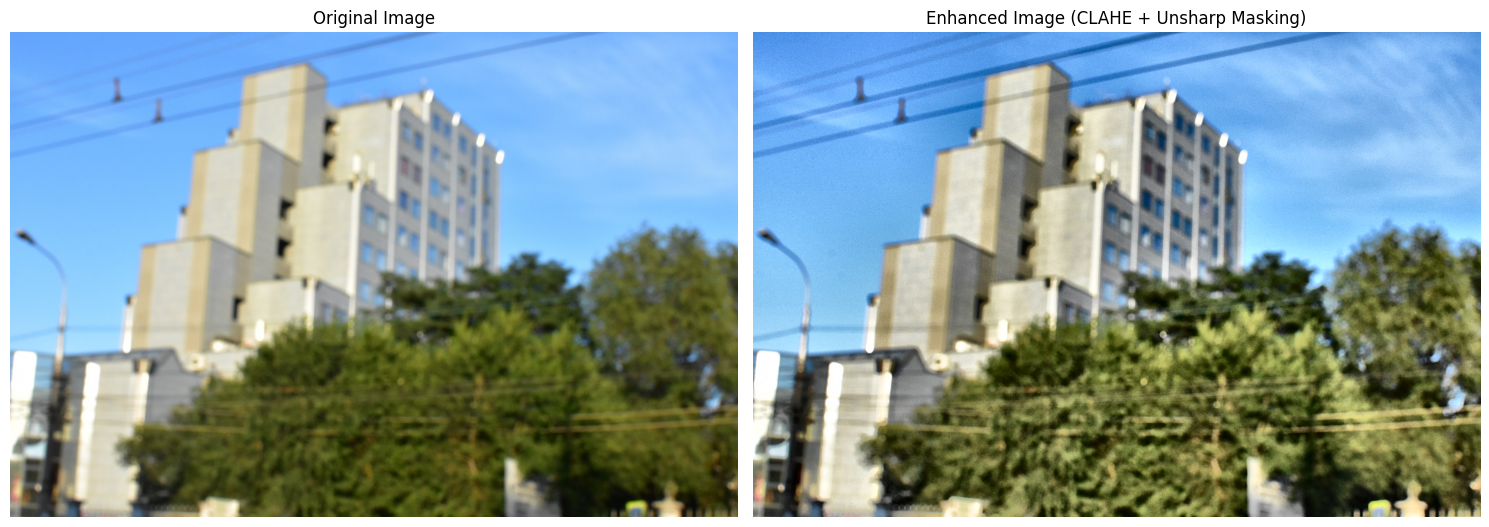

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def lightweight_enhance(img_bgr):
    # 1. CLAHE for local contrast
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    enhanced_lab = cv2.merge((cl, a, b))
    enhanced_bgr = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)
    
    # 2. Unsharp Masking
    gaussian_blur = cv2.GaussianBlur(enhanced_bgr, (0, 0), 3.0)
    sharpened = cv2.addWeighted(enhanced_bgr, 1.5, gaussian_blur, -0.5, 0)
    
    return sharpened

# Load original
img_path = '/Users/muhajav/Documents/Computer Vision/CVL_Assignment01/Blurred Image Enchancement/data/blurredImage.JPG'
original_img = cv2.imread(img_path)
enhanced_img = lightweight_enhance(original_img)

# Convert BGR to RGB for correct display in matplotlib
original_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
enhanced_rgb = cv2.cvtColor(enhanced_img, cv2.COLOR_BGR2RGB)

# Create a figure with 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Plot Original
axes[0].imshow(original_rgb)
axes[0].set_title("Original Image")
axes[0].axis('off')

# Plot Enhanced
axes[1].imshow(enhanced_rgb)
axes[1].set_title("Enhanced Image (CLAHE + Unsharp Masking)")
axes[1].axis('off')

plt.tight_layout()
plt.show()